# NLP Preprocessing and Text Classification Assignment


For this assignment, we will use the **20 Newsgroups dataset**, a classic dataset for text classification. It consists of approximately 18,000 newsgroup documents, partitioned (nearly) evenly across 20 different newsgroups.

In [11]:
from sklearn.datasets import fetch_20newsgroups

categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, random_state=42)

print(f"Number of training samples: {len(newsgroups_train.data)}")
print(f"Number of test samples: {len(newsgroups_test.data)}")
print(f"Categories: {newsgroups_train.target_names}")

print("\n--- Example Document ---")
print(f"Category: {newsgroups_train.target_names[newsgroups_train.target[0]]}")
print(newsgroups_train.data[0])

Number of training samples: 2257
Number of test samples: 1502
Categories: ['alt.atheism', 'comp.graphics', 'sci.med', 'soc.religion.christian']

--- Example Document ---
Category: comp.graphics
From: sd345@city.ac.uk (Michael Collier)
Subject: Converting images to HP LaserJet III?
Nntp-Posting-Host: hampton
Organization: The City University
Lines: 14

Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.
-- 
Michael Collier (Programmer)                 The Computer Unit,
Email: M.P.Collier@uk.ac.city                The City University,
Tel: 071 477-8000 x3769                      London,
Fax: 071 477-8565                            EC1V 0HB.



## NLP Preprocessing

We will now apply several NLP preprocessing techniques to clean and prepare our text data for model training. These steps include:

1.  **Text Cleaning**: Removing unwanted characters, converting to lowercase.
2.  **Tokenization**: Breaking down text into individual words or tokens.
3.  **Stopword Removal**: Eliminating common words that don't add much meaning.
4.  **Lemmatization**: Reducing words to their base or dictionary form.

In [5]:
# Import necessary libraries for NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    # Added download for 'punkt_tab' as indicated by the error
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

print("NLTK data (stopwords, wordnet, punkt, punkt_tab) downloaded/verified.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK data (stopwords, wordnet, punkt, punkt_tab) downloaded/verified.


In [6]:
# Initialize WordNet Lemmatizer and Stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Text Cleaning: Remove special characters and numbers, convert to lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text) # Keep only letters
    text = text.lower()

    # 2. Tokenization: Split text into words
    words = word_tokenize(text)

    # 3. Stopword Removal and 4. Lemmatization
    processed_words = []
    for word in words:
        if word not in stop_words and len(word) > 1: # Remove single character words as well
            processed_words.append(lemmatizer.lemmatize(word))

    return ' '.join(processed_words)

# Apply preprocessing to the training and test data
print("Applying preprocessing to training data...")
X_train_preprocessed = [preprocess_text(doc) for doc in newsgroups_train.data]
print("Applying preprocessing to test data...")
X_test_preprocessed = [preprocess_text(doc) for doc in newsgroups_test.data]

y_train = newsgroups_train.target
y_test = newsgroups_test.target

print("\n--- Original vs. Preprocessed Example ---")
print(f"Original: {newsgroups_train.data[0]}\n")
print(f"Preprocessed: {X_train_preprocessed[0]}")
print(f"Target: {y_train[0]}")

Applying preprocessing to training data...
Applying preprocessing to test data...

--- Original vs. Preprocessed Example ---
Original: From: sd345@city.ac.uk (Michael Collier)
Subject: Converting images to HP LaserJet III?
Nntp-Posting-Host: hampton
Organization: The City University
Lines: 14

Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.
-- 
Michael Collier (Programmer)                 The Computer Unit,
Email: M.P.Collier@uk.ac.city                The City University,
Tel: 071 477-8000 x3769                      London,
Fax: 071 477-8565                            EC1V 0HB.


Preprocessed: sd city ac uk michael collier subject converting image hp laserjet iii nntp posting host hampton organization city university line anyone know good way standard pc

## Text Vectorization

Now, we will convert the preprocessed text data into numerical features using two common vectorization techniques:

1.  **CountVectorizer**: Converts a collection of text documents to a matrix of token counts.
2.  **TF-IDF Vectorizer**: Transforms text into a matrix where each value represents the TF-IDF (Term Frequency-Inverse Document Frequency) score, reflecting the importance of a word in a document relative to the corpus.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. CountVectorizer
print("Applying CountVectorizer...")
count_vectorizer = CountVectorizer()
X_train_counts = count_vectorizer.fit_transform(X_train_preprocessed)
X_test_counts = count_vectorizer.transform(X_test_preprocessed)

print(f"CountVectorizer - X_train_counts shape: {X_train_counts.shape}")
print(f"CountVectorizer - X_test_counts shape: {X_test_counts.shape}")

# 2. TF-IDF Vectorizer
print("\nApplying TF-IDF Vectorizer...")
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_preprocessed)
X_test_tfidf = tfidf_vectorizer.transform(X_test_preprocessed)

print(f"TF-IDF Vectorizer - X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"TF-IDF Vectorizer - X_test_tfidf shape: {X_test_tfidf.shape}")

Applying CountVectorizer...
CountVectorizer - X_train_counts shape: (2257, 28157)
CountVectorizer - X_test_counts shape: (1502, 28157)

Applying TF-IDF Vectorizer...
TF-IDF Vectorizer - X_train_tfidf shape: (2257, 28157)
TF-IDF Vectorizer - X_test_tfidf shape: (1502, 28157)


## Text Classification Model Training and Evaluation

Now that our text data is vectorized, we can train a classification model. We'll use the **Multinomial Naive Bayes** classifier, a probabilistic algorithm particularly well-suited for text classification tasks, as it works well with discrete features like word counts.

We will evaluate the model's performance using standard metrics such as:
*   **Accuracy**: The proportion of correctly classified instances.
*   **Precision**: The proportion of positive identifications that were actually correct.
*   **Recall**: The proportion of actual positives that were identified correctly.
*   **F1-Score**: The harmonic mean of precision and recall.
*   **Confusion Matrix**: A table used to describe the performance of a classification model on a set of test data for which the true values are known.

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_evaluate_model(X_train, y_train, X_test, y_test, vectorizer_name, target_names):
    print(f"\n--- Training and Evaluating with {vectorizer_name} Features ---")

    # Initialize and train the Multinomial Naive Bayes classifier
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {vectorizer_name}')
    plt.show()

    return model, y_pred

### Model with CountVectorizer Features


--- Training and Evaluating with CountVectorizer Features ---
Accuracy: 0.9414
Precision: 0.9415
Recall: 0.9414
F1-Score: 0.9413


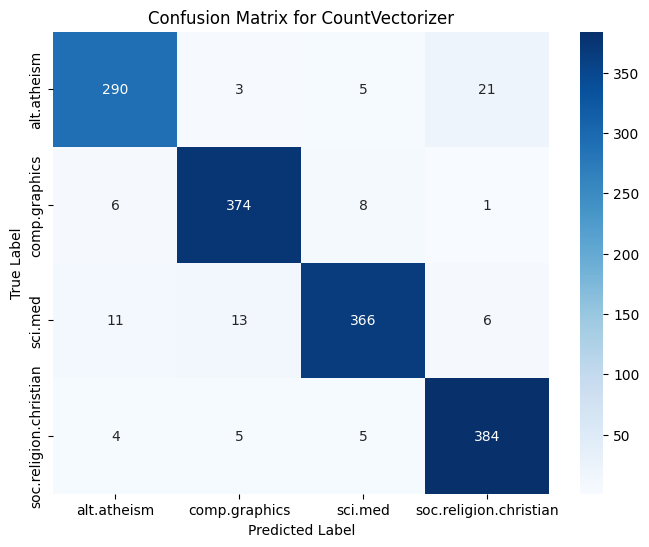

In [9]:
mnb_count_model, y_pred_counts = train_and_evaluate_model(
    X_train_counts, y_train, X_test_counts, y_test,
    "CountVectorizer", newsgroups_train.target_names
)

### Model with TF-IDF Vectorizer Features


--- Training and Evaluating with TF-IDF Vectorizer Features ---
Accuracy: 0.8901
Precision: 0.9042
Recall: 0.8901
F1-Score: 0.8901


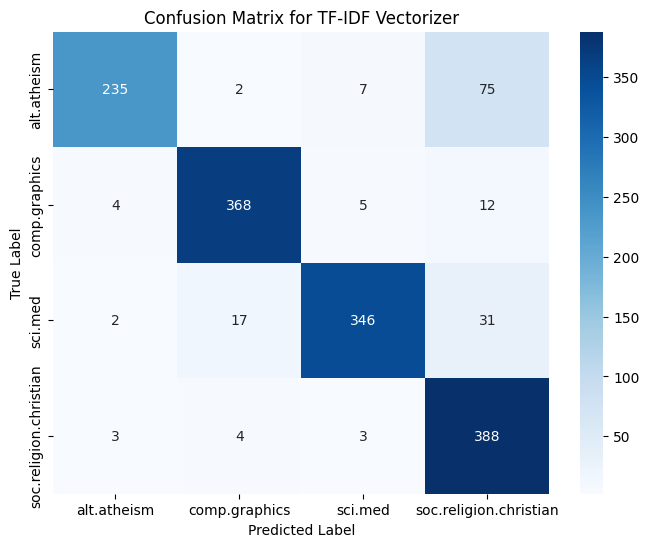

In [10]:
mnb_tfidf_model, y_pred_tfidf = train_and_evaluate_model(
    X_train_tfidf, y_train, X_test_tfidf, y_test,
    "TF-IDF Vectorizer", newsgroups_train.target_names
)